In [1]:
import numpy as np

In [2]:
#defining the states
states = ["h", "e", "l", "o"]
n_states = len(states)

#initial probabilities as given in the question
pi = np.array([1.0, 0.0, 0.0, 0.0])

#transition probability matrix (A)
A = np.array([
    [0.0, 0.7, 0.3, 0.0],
    [0.0, 0.2, 0.6, 0.2],
    [0.0, 0.0, 0.3, 0.7],
    [0.0, 0.0, 0.1, 0.9]
])

#omission probability matrix (B)
B = np.array([
    [0.6, 0.2, 0.1, 0.1],
    [0.1, 0.7, 0.1, 0.1],
    [0.1, 0.1, 0.6, 0.2],
    [0.2, 0.1, 0.2, 0.5]
])

#observation sequence O = [O1, O2, O3, O4]
observations = [0, 1, 2, 3]

#viterbi algorithm
T = len(observations)
delta = np.zeros((T, n_states))
psi = np.zeros((T, n_states), dtype=int)

#initialisation
delta[0] = pi * B[:, observations[0]]

#recursion
for t in range(1, T):
    for s in range(n_states):
        prob = delta[t-1] * A[:, s]
        psi[t, s] = np.argmax(prob)
        delta[t, s] = np.max(prob) * B[s, observations[t]]

#backtracking
states_sequence_idx = np.zeros(T, dtype=int)
states_sequence_idx[-1] = np.argmax(delta[-1])

for t in range(T-2, -1, -1):
    states_sequence_idx[t] = psi[t+1, states_sequence_idx[t+1]]

most_probable_sequence = [states[i] for i in states_sequence_idx]
most_probable_prob = np.max(delta[-1])

In [3]:
print("most likely phoneme sequence:", most_probable_sequence)

most likely phoneme sequence: ['h', 'e', 'l', 'o']


In [4]:
print("probability:", most_probable_prob)

probability: 0.03704399999999999


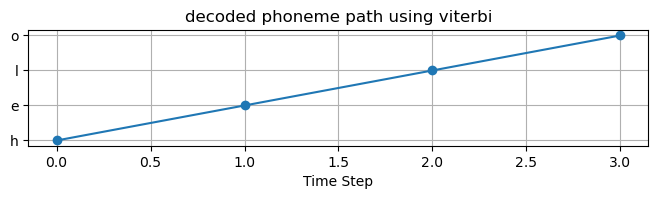

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 1.5))
plt.title("decoded phoneme path using viterbi")
plt.plot(most_probable_sequence, marker="o", linestyle="-")
plt.yticks(most_probable_sequence)
plt.xlabel("Time Step")
plt.grid(True)
plt.show()

In [6]:
#using real voice

In [1]:
pip install numpy scipy librosa sounddevice soundfile matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import sounddevice as sd
import soundfile as sf
import librosa
import os
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

In [3]:
#HMM parameters 
states = ["h", "e", "l", "o"]
n_states = len(states)

In [4]:
pi = np.array([1.0, 0.0, 0.0, 0.0])

A = np.array([
    [0.0, 0.7, 0.3, 0.0],
    [0.0, 0.2, 0.6, 0.2],
    [0.0, 0.0, 0.3, 0.7],
    [0.0, 0.0, 0.1, 0.9]
])

In [5]:
#emission probabilities
B_default = np.array([
    [0.6, 0.2, 0.1, 0.1],
    [0.1, 0.7, 0.1, 0.1],
    [0.1, 0.1, 0.6, 0.2],
    [0.2, 0.1, 0.2, 0.5]
])

In [6]:
SR = 16000  # sampling rate
def record_audio(duration_s, prompt="Recording"):
    print(f">> {prompt} (duration {duration_s}s). Speak after the beep.")
    sd.sleep(300)  # tiny pause so prompt is visible
    sd.play(np.sin(2*np.pi*440*np.linspace(0,0.05,int(SR*0.05))), samplerate=SR)  # tiny beep
    sd.wait()
    recording = sd.rec(int(duration_s * SR), samplerate=SR, channels=1, dtype='float32')
    sd.wait()
    audio = recording[:,0]
    return audio

def save_wav(audio, filename):
    sf.write(filename, audio, SR)
    print(f"Saved: {filename}")

In [8]:
#feature extraction
def compute_mean_mfcc(audio, sr=SR, n_mfcc=13):
    audio = librosa.util.normalize(audio.astype(np.float32))
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, n_fft=512, hop_length=256)
    return np.mean(mfcc, axis=1)

In [9]:
def viterbi_discrete(observations, A, B, pi):
    T = len(observations)
    n_states = A.shape[0]
    delta = np.zeros((T, n_states))
    psi = np.zeros((T, n_states), dtype=int)

    #initialisation
    delta[0] = pi * B[:, observations[0]]

    #recursion
    for t in range(1, T):
        for s in range(n_states):
            prob = delta[t-1] * A[:, s]
            psi[t, s] = np.argmax(prob)
            delta[t, s] = np.max(prob) * B[s, observations[t]]

    #backtracking
    seq_idx = np.zeros(T, dtype=int)
    seq_idx[-1] = np.argmax(delta[-1])
    for t in range(T-2, -1, -1):
        seq_idx[t] = psi[t+1, seq_idx[t+1]]

    prob = np.max(delta[-1])
    return seq_idx, prob, delta

We will record prototypes for O1..O4. Each should be a short sound that corresponds to:
O1 ~ sound vector for /h/ ; O2 ~ /e/ ; O3 ~ /l/ ; O4 ~ /o/
For best results, say a short sustained phoneme or a short example of the target sound (0.4-0.8s).
>> Recording prototype O1 (h) (duration 0.7s). Speak after the beep.
Saved: recordings/proto_O1_h.wav
>> Recording prototype O2 (e) (duration 0.7s). Speak after the beep.
Saved: recordings/proto_O2_e.wav
>> Recording prototype O3 (l) (duration 0.7s). Speak after the beep.
Saved: recordings/proto_O3_l.wav
>> Recording prototype O4 (o) (duration 0.7s). Speak after the beep.
Saved: recordings/proto_O4_o.wav

Prototypes' MFCC shapes: (4, 13)
>> Recording full word 'hello' (2.0s) (duration 2.0s). Speak after the beep.
Saved: recordings/hello_recording.wav
Segment 1: distances [30.035 24.594 65.287 59.038] -> obs O2
Segment 2: distances [47.996 60.103 27.052 17.106] -> obs O4
Segment 3: distances [ 94.195 105.999  44.438  53.037] -> obs O3
Segment 4:

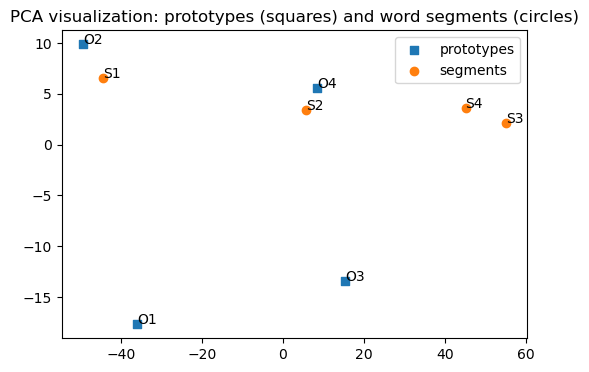

In [ ]:
def interactive_run():
    os.makedirs("recordings", exist_ok=True)

    print("We will record prototypes for O1..O4. Each should be a short sound that corresponds to:")
    print("O1 ~ sound vector for /h/ ; O2 ~ /e/ ; O3 ~ /l/ ; O4 ~ /o/")
    print("For best results, say a short sustained phoneme or a short example of the target sound (0.4-0.8s).")

    prototype_mfccs = []
    for i, state in enumerate(states):
        input(f"\nPrepare to record prototype for observation O{i+1} (phoneme for state '{state}'). Press Enter when ready.")
        audio = record_audio(duration_s=0.7, prompt=f"Recording prototype O{i+1} ({state})")
        fn = f"recordings/proto_O{i+1}_{state}.wav"
        save_wav(audio, fn)
        mfcc = compute_mean_mfcc(audio)
        prototype_mfccs.append(mfcc)

    prototype_mfccs = np.stack(prototype_mfccs)  # shape (4, n_mfcc)
    print("\nPrototypes' MFCC shapes:", prototype_mfccs.shape)

    input("\nNow prepare to record yourself saying the whole word 'hello' once, clearly. Press Enter when ready.")
    audio_whole = record_audio(duration_s=2.0, prompt="Recording full word 'hello' (2.0s)")
    fn_whole = "recordings/hello_recording.wav"
    save_wav(audio_whole, fn_whole)

    total_len = audio_whole.shape[0]
    seg_len = total_len // 4
    obs_sequence = []
    seg_mfccs = []
    for seg in range(4):
        start = seg * seg_len
        end = start + seg_len if seg < 3 else total_len
        segment = audio_whole[start:end]
        mfcc_seg = compute_mean_mfcc(segment)
        seg_mfccs.append(mfcc_seg)
        
        dists = cdist([mfcc_seg], prototype_mfccs, metric='euclidean')[0]
        obs_idx = int(np.argmin(dists))
        obs_sequence.append(obs_idx)
        print(f"Segment {seg+1}: distances {np.round(dists,3)} -> obs O{obs_idx+1}")

    print("\nDiscrete observation sequence from recording:", [f"O{i+1}" for i in obs_sequence])

    B_est = np.full((n_states, n_states), 0.05)  # small base prob
    for s in range(n_states):
        B_est[s, s] = 0.8
    # renormalize rows
    B_est = B_est / B_est.sum(axis=1, keepdims=True)
    print("\nEstimated discrete emission matrix B_est (rows=states, cols=observations):\n", B_est)


    obs_seq = obs_sequence
    seq_idx, prob, delta = viterbi_discrete(obs_seq, A, B_est, pi)

    decoded_states = [states[i] for i in seq_idx]
    print("\nDecoded phoneme sequence:", decoded_states)
    print("Viterbi probability (approx):", prob)

    try:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        X = np.vstack([prototype_mfccs, np.stack(seg_mfccs)])
        Xp = pca.fit_transform(X)
        prot2 = Xp[:4]
        seg2 = Xp[4:]
        plt.figure(figsize=(6,4))
        plt.scatter(prot2[:,0], prot2[:,1], marker='s', label='prototypes')
        for i,p in enumerate(prot2):
            plt.annotate(f"O{i+1}", (p[0], p[1]))
        plt.scatter(seg2[:,0], seg2[:,1], marker='o', label='segments')
        for i,s in enumerate(seg2):
            plt.annotate(f"S{i+1}", (s[0], s[1]))
        plt.legend()
        plt.title("PCA visualization: prototypes (squares) and word segments (circles)")
        plt.show()
    except Exception as e:
        print("PCA visualization skipped (install scikit-learn to enable).", e)

if __name__ == "__main__":
    interactive_run()